# Forward simulator — a mechanochemical epithelial–mesenchymal case study


## 0. Setup

We render off-screen (headless) so every figure embeds as a static image in the
docs.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

import pyglet
pyglet.options["headless"] = True
import pyvista as pv
pv.OFF_SCREEN = True

import warp as wp
from waxmorph import simulator, render

wp.init()
device = "cuda"
np.random.seed(42)

# --- Tutorial-scale configuration -------------------------------------------
N0 = 100                 # initial number of cells
N_MES = 14               # mesenchymal cells (soft, patterning core)
N_EPI = N0 - N_MES       # epithelial cells (polarized enclosing shell)
MAX_PARTICLES = 30_000   # preallocated capacity that division grows into
TARGET_CELLS = 15_000    # stop the morphogenesis loop at this many cells

# Cell-type codes shared with the Warp kernels: epithelial cells are encoded 1.
MES, EPI = 0, 1


In [2]:
def _auto_limits(pos, radii, pad=1.35):
    """A cubic view box that comfortably contains a cloud."""
    lo = float((pos.min(axis=0) - radii.max()).min())
    hi = float((pos.max(axis=0) + radii.max()).max())
    c, half = 0.5 * (lo + hi), 0.5 * (hi - lo) * pad
    return c - half, c + half


def render_cloud(pos, radii, *, cell_types=None, activator=None, title=None,
                 limits=None, window_size=(560, 480), theta_res=10, phi_res=6):
    """Screenshot a cell cloud off-screen, tinted by cell type or activator.

    Rendering statically (rather than as an interactive widget) makes the figure
    embed reliably in the built HTML docs.
    """
    n = len(pos)
    if activator is not None:
        a = np.asarray(activator, np.float32)
        morph = (a - a.min()) / (np.ptp(a) + 1e-9) * 0.9
    else:
        morph = np.zeros(n, np.float32)
    pol = np.zeros((n, 3), np.float32)
    pol[:, 2] = 1.0
    blim, tlim = limits if limits is not None else _auto_limits(pos, radii)
    plotter = render.PyVistaInterface.draw_3d_view(
        pos, radii, morph, pol, n, blim=blim, tlim=tlim, alpha=1.0,
        theta_res=theta_res, phi_res=phi_res, show_polarities=False,
        cell_types=None if cell_types is None else np.asarray(cell_types),
    )
    plotter.remove_bounds_axes()
    plotter.hide_axes()          # drop the little XYZ orientation gizmo
    img = plotter.screenshot(return_img=True, window_size=window_size)
    plotter.close()
    fig, ax = plt.subplots(figsize=(window_size[0] / 120, window_size[1] / 120))
    ax.imshow(img)
    ax.axis("off")
    if title:
        ax.set_title(title, fontsize=10)
    plt.show()


def render_filmstrip(snaps, *, title=None, window_size=(300, 280)):
    """Lay out several ``(label, pos, radii, cell_types)`` snapshots side by side.

    All frames share one view box (taken from the largest snapshot) so the growth
    of the aggregate is visible across the strip.
    """
    big_pos, big_rad = snaps[-1][1], snaps[-1][2]
    limits = _auto_limits(big_pos, big_rad)
    shots = []
    for label, pos, radii, ct in snaps:
        n = len(pos)
        pol = np.zeros((n, 3), np.float32)
        pol[:, 2] = 1.0
        plotter = render.PyVistaInterface.draw_3d_view(
            pos, radii, np.zeros(n, np.float32), pol, n, blim=limits[0],
            tlim=limits[1], alpha=1.0, theta_res=8, phi_res=6,
            show_polarities=False, cell_types=np.asarray(ct),
        )
        plotter.remove_bounds_axes()
        plotter.hide_axes()
        shots.append((label, plotter.screenshot(return_img=True, window_size=window_size)))
        plotter.close()
    fig, axes = plt.subplots(1, len(shots), figsize=(2.6 * len(shots), 2.8))
    for ax, (label, im) in zip(np.atleast_1d(axes), shots):
        ax.imshow(im)
        ax.axis("off")
        ax.set_title(label, fontsize=9)
    if title:
        fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()


## 1. Initialise the aggregate


In [3]:
def fibonacci_sphere(n, radius):
    """`n` near-uniform points on a sphere of the given radius."""
    i = np.arange(n)
    phi = np.pi * (3.0 - np.sqrt(5.0))       # golden angle
    y = 1.0 - 2.0 * i / (n - 1)
    r = np.sqrt(np.clip(1.0 - y * y, 0.0, None))
    theta = phi * i
    return np.stack([np.cos(theta) * r * radius, y * radius,
                     np.sin(theta) * r * radius], axis=1)


def uniform_ball(n, radius):
    """`n` points sampled uniformly by volume inside a ball."""
    v = np.random.normal(size=(n, 3))
    v /= np.linalg.norm(v, axis=1, keepdims=True)
    return v * (np.random.rand(n) ** (1 / 3) * radius)[:, None]


R_SHELL, R_INNER, R_PROTO = 3.0, 1.8, 0.6

# Positions: mesenchymal ball inside, epithelial shell outside, with a little jitter.
centers = np.zeros((MAX_PARTICLES, 3), np.float32)
centers[:N_MES] = uniform_ball(N_MES, R_INNER)
centers[N_MES:N0] = fibonacci_sphere(N_EPI, R_SHELL)
centers[:N0] += 0.05 * np.random.normal(size=(N0, 3))

# Radii: physical and equilibrium start equal; inactive slots are parked far below zero.
radii = np.full(MAX_PARTICLES, -1000.0, np.float32)
radii_eq = np.full(MAX_PARTICLES, -1000.0, np.float32)
radii[:N0] = R_PROTO
radii_eq[:N0] = R_PROTO

# Activator / inhibitor: seed the mesenchyme only (ratio ~5); the epithelium carries none.
activators = np.zeros(MAX_PARTICLES, np.float32)
inhibitors = np.zeros(MAX_PARTICLES, np.float32)
a0 = (R_PROTO ** 3 * 0.75) / 2.0
activators[:N_MES] = a0 + 1e-3 * np.random.normal(size=N_MES)
inhibitors[:N_MES] = a0 / 5.0 + 1e-3 * np.random.normal(size=N_MES)

# Polarity: unit vectors pointing radially outward from the aggregate centre.
polarities = np.zeros((MAX_PARTICLES, 3), np.float32)
polarities[:, 2] = 1.0
d = centers[:N0] - centers[:N0].mean(axis=0)
polarities[:N0] = d / np.clip(np.linalg.norm(d, axis=1, keepdims=True), 1e-9, None)

# Cell type: 0 = mesenchymal, 1 = epithelial.
cell_types = np.full(MAX_PARTICLES, EPI, np.uint32)
cell_types[:N_MES] = MES

# Upload the state to the GPU as Warp arrays.
X = wp.from_numpy(centers, dtype=wp.vec3f, device=device)
R = wp.from_numpy(radii, dtype=wp.float32, device=device)
R_eq = wp.from_numpy(radii_eq, dtype=wp.float32, device=device)
P = wp.from_numpy(polarities, dtype=wp.vec3f, device=device)
A = wp.from_numpy(activators, dtype=wp.float32, device=device)
I = wp.from_numpy(inhibitors, dtype=wp.float32, device=device)
CT = wp.from_numpy(cell_types, dtype=wp.uint32, device=device)
keys = simulator.gen_key_array(MAX_PARTICLES)   # per-cell RNG keys for division/growth

pcount = N0
print(f"{N0} cells: {N_MES} mesenchymal core + {N_EPI} epithelial shell")


Module waxmorph.simulator 0df436c load on device 'cuda:0' took 501.68 ms  (compiled)
100 cells: 14 mesenchymal core + 86 epithelial shell


### The starting aggregate

We colour cells by **type** — the epithelial shell wraps the mesenchymal core.
A cutaway (keeping one half) reveals the soft interior the shell encloses.


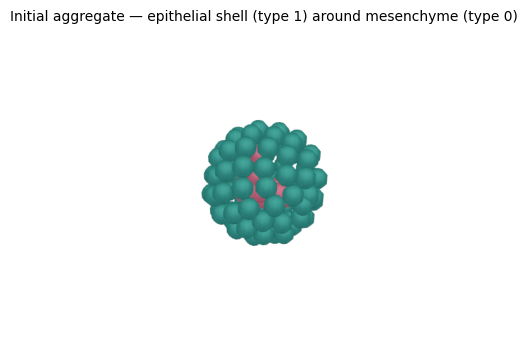

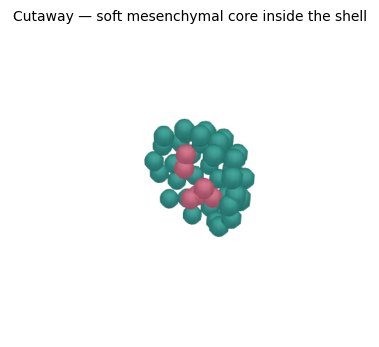

In [4]:
pos0, rad0, ct0 = X.numpy()[:pcount], R.numpy()[:pcount], CT.numpy()[:pcount]
render_cloud(pos0, rad0, cell_types=ct0,
             title="Initial aggregate — epithelial shell (type 1) around mesenchyme (type 0)")

# Cutaway: keep the x <= mean half so the core is visible inside the shell.
half = pos0[:, 0] <= pos0[:, 0].mean()
render_cloud(pos0[half], rad0[half], cell_types=ct0[half],
             title="Cutaway — soft mesenchymal core inside the shell")


## 2. Sticky-sphere mechanics

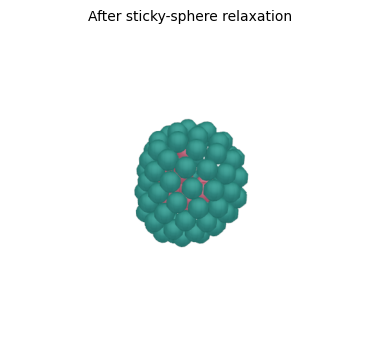

In [5]:
DT_MECH = 5e-2
for _ in range(600):
    simulator.mech_step_sticky(X, R, P, CT, pcount, DT_MECH, X, P, grad_consist=False)

render_cloud(X.numpy()[:pcount], R.numpy()[:pcount], cell_types=CT.numpy()[:pcount],
             title="After sticky-sphere relaxation")


## 3. Reaction–diffusion patterning

In [6]:
CHI = wp.full(1, 5e-3, dtype=wp.float32)      # activator diffusivity relative to inhibitor
GAMMA = wp.full(1, 1e-3, dtype=wp.float32)    # reaction rate (1e-3 -> branching; 1e-2 -> undulation)
D_INHIB = 10.0                                # inhibitor diffusivity
DT_CHEM = 5e-2
lapA, lapI = wp.zeros_like(A), wp.zeros_like(I)

a_trace, i_trace = [], []
for _ in range(4000):
    lapA.zero_()
    lapI.zero_()
    simulator.chem_step(A, I, X, R, lapA, lapI, CHI, GAMMA, D_INHIB, DT_CHEM,
                        pcount, A, I, grad_consist=False, CT=CT, reaction_cell_type=MES)
    a_trace.append(float(A.numpy()[0]))
    i_trace.append(float(I.numpy()[0]))

print(f"cell 0 settled at activator={a_trace[-1]:.3f}, inhibitor={i_trace[-1]:.3f}")


cell 0 settled at activator=0.505, inhibitor=0.614


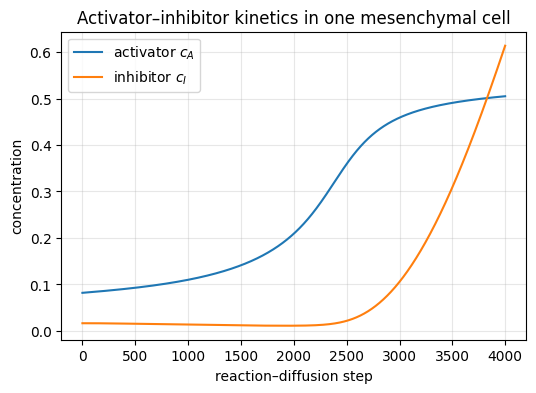

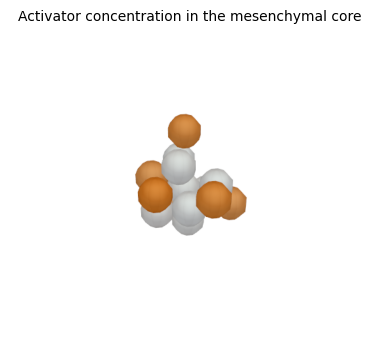

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(a_trace, label=r"activator $c_A$")
ax.plot(i_trace, label=r"inhibitor $c_I$")
ax.set_xlabel("reaction–diffusion step")
ax.set_ylabel("concentration")
ax.set_title("Activator–inhibitor kinetics in one mesenchymal cell")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

# The activator field lives in the core; show the mesenchyme coloured by activator.
mes = CT.numpy()[:pcount] == MES
render_cloud(X.numpy()[:pcount][mes], R.numpy()[:pcount][mes],
             activator=A.numpy()[:pcount][mes],
             title="Activator concentration in the mesenchymal core")


## 4. Growth

radius range after growth: 0.60 – 1.12 (mesenchyme swells; epithelium stays near 0.6)


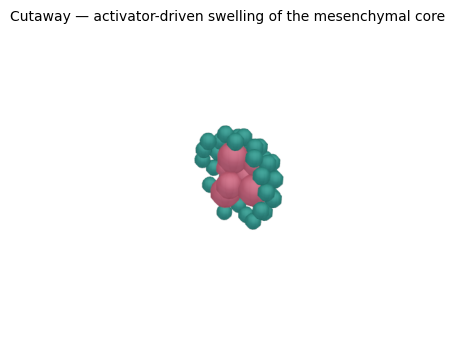

In [8]:
ALPHA_GROW = wp.full(1, 10.0, dtype=wp.float32, requires_grad=True)  # growth Hill exponent
ELL_SW = wp.full(1, 0.5, dtype=wp.float32, requires_grad=True)       # switch concentration
DT_GROWTH = 5e-3
R_REF, R_MAX = 0.6, 1.4      # epithelial reference radius; mesenchymal equilibrium cap

# A short, division-free growth phase so the swelling is visible on its own.
# (Sustained growth without division would overfill the shell; in Section 5 the
# epithelium divides to keep pace, so the core stays enclosed.)
for _ in range(1000):
    simulator.mech_step_sticky(X, R, P, CT, pcount, DT_MECH, X, P, grad_consist=False)
    simulator.growth_step(R, R_eq, A, CT, keys, ALPHA_GROW, ELL_SW, DT_GROWTH,
                          R_REF, R_MAX, pcount, R, R_eq, grad_consist=False)

r_now = R.numpy()[:pcount]
print(f"radius range after growth: {r_now.min():.2f} – {r_now.max():.2f} "
      f"(mesenchyme swells; epithelium stays near {R_REF})")

# Cutaway again: the mesenchymal cells (type 0) have swelled inside the shell.
pos, rad, ct = X.numpy()[:pcount], R.numpy()[:pcount], CT.numpy()[:pcount]
half = pos[:, 0] <= pos[:, 0].mean()
render_cloud(pos[half], rad[half], cell_types=ct[half],
             title="Cutaway — activator-driven swelling of the mesenchymal core")


## 5. Division and morphogenesis

In [9]:
R_DIV_REF = 1.0            # division reference radius (mesenchymal Hill)
EPI_MAX_NEIGHBORS = 6      # epithelial monolayer neighbour cap
P_EPI = 1.0                # epithelial division probability when eligible
SUBSTEPS = 20              # mechanics + chemistry sub-steps per outer iteration
t_div, tmax, tau = 1.0, 1.0, 1.0   # Gumbel-softmax division-sampling controls

n_tot = wp.zeros(MAX_PARTICLES, dtype=wp.int32, device=device)
n_epi = wp.zeros(MAX_PARTICLES, dtype=wp.int32, device=device)
n_mes = wp.zeros(MAX_PARTICLES, dtype=wp.int32, device=device)

def snapshot(label):
    return (label, X.numpy()[:pcount].copy(), R.numpy()[:pcount].copy(),
            CT.numpy()[:pcount].copy())

snaps = [snapshot(f"{pcount} cells")]
milestones = [1000, 3000, 7000, TARGET_CELLS]

while pcount < TARGET_CELLS:
    for _ in range(SUBSTEPS):
        lapA.zero_(); lapI.zero_()
        simulator.mech_step_sticky(X, R, P, CT, pcount, DT_MECH, X, P, grad_consist=False)
        simulator.chem_step(A, I, X, R, lapA, lapI, CHI, GAMMA, D_INHIB, DT_CHEM,
                            pcount, A, I, grad_consist=False, CT=CT, reaction_cell_type=MES)
    simulator.growth_step(R, R_eq, A, CT, keys, ALPHA_GROW, ELL_SW, DT_GROWTH,
                          R_REF, R_MAX, pcount, R, R_eq, grad_consist=False)

    n_tot.zero_(); n_epi.zero_(); n_mes.zero_()
    simulator.count_neighbors_step(X, R, CT, pcount, n_tot, n_epi, n_mes, device=device)

    div_count = wp.full(1, value=pcount, dtype=wp.int32, device=device)
    div_slots = wp.full(pcount, value=-1, dtype=wp.int32, device=device)
    wp.launch(simulator.division_decision, dim=pcount,
              inputs=[X, R, CT, keys, n_epi, n_mes, div_count, div_slots,
                      R_DIV_REF, P_EPI, EPI_MAX_NEIGHBORS, t_div, tmax, tau, MAX_PARTICLES],
              device=device)
    wp.launch(simulator.division_logic, dim=pcount,
              inputs=[X, R, R_eq, A, I, P, CT, div_slots], device=device)
    pcount = min(int(div_count.numpy().item()), MAX_PARTICLES)

    if milestones and pcount >= milestones[0]:
        snaps.append(snapshot(f"{pcount} cells"))
        milestones.pop(0)

print(f"grew to {pcount} cells")


grew to 15005 cells


The filmstrip below traces the aggregate from a smooth sphere to an elongated,
deformed shape; the final render shows the reshaped epithelial shell.


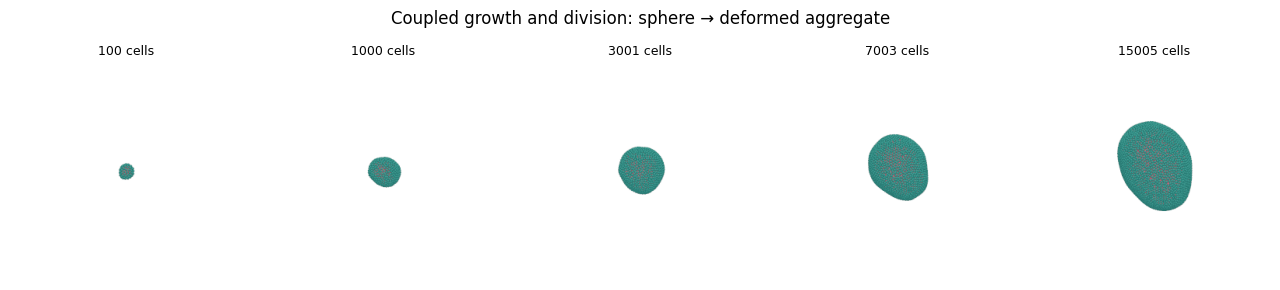

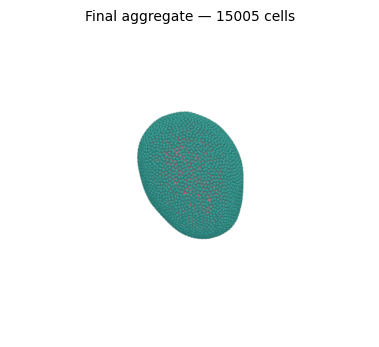

In [10]:
render_filmstrip(snaps, title="Coupled growth and division: sphere → deformed aggregate")
render_cloud(X.numpy()[:pcount], R.numpy()[:pcount], cell_types=CT.numpy()[:pcount],
             title=f"Final aggregate — {pcount} cells")


## 6. The differentiable path

In [11]:
X_a = wp.from_numpy(centers.copy(), dtype=wp.vec3f, device=device)
P_a = wp.from_numpy(polarities.copy(), dtype=wp.vec3f, device=device)
X_d = wp.from_numpy(centers.copy(), dtype=wp.vec3f, device=device)
P_d = wp.from_numpy(polarities.copy(), dtype=wp.vec3f, device=device)

for _ in range(200):
    simulator.mech_step_sticky(X_a, R, P_a, CT, N0, DT_MECH, X_a, P_a, grad_consist=False)
    simulator.mech_step_sticky_implicit(X_d, R, P_d, CT, N0, DT_MECH, X_d, P_d)

gap = np.abs(X_a.numpy()[:N0] - X_d.numpy()[:N0]).max()
print(f"max position difference (analytic vs autodiff) after 200 steps: {gap:.2e}")


max position difference (analytic vs autodiff) after 200 steps: 5.96e-07


## 7. (Optional) Export a movie


In [12]:
import os
os.makedirs("Output", exist_ok=True)

with render.WarpMovieRenderer(
    filename="Output/epi_mes_morphogenesis.usd",
    max_particles=MAX_PARTICLES,
    backend="usd",
    fps=8,
    device=device,
) as mov:
    for f, (label, pos, radii, ct) in enumerate(snaps):
        n = len(pos)
        colors = np.where((ct == EPI)[:, None], [0.85, 0.55, 0.25], [0.30, 0.55, 0.85]).astype(np.float32)
        mov.write_frame_from_numpy(
            t=f / 8.0, centers=pos, radii=radii, colors=colors, particle_count=n,
        )
print("wrote Output/epi_mes_morphogenesis.usd")


Saved the USD stage file at `/insomnia001/depts/morpheus/users/ob2391/Waxmorph/Output/epi_mes_morphogenesis.usd`
wrote Output/epi_mes_morphogenesis.usd
